# Atlantic Tropical Cyclone Tracks (HURDAT2)

This notebook downloads and parses the NOAA/AOML **HURDAT2** Atlantic best-track dataset
(https://www.aoml.noaa.gov/hrd/hurdat/hurdat2.html) and produces:

1. A map of **all named Atlantic storm tracks**, color-coded by intensity (Saffir–Simpson scale),
   styled to resemble NHC's own track maps.
2. An **interactive lookup** that lets you plot a single storm's track by name and year.


### NCSU Tropical and Large Scale Dynamics
### Code by A. Aiyyer with help from Claude AI
### AI Usage declaration:
- Claude Code used to debug code and improve efficiency

## 1. Packages needed

In [11]:
import os
import re
import datetime as dt
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature


## 2. Download the HURDAT2 Atlantic best-track file

In [12]:
dataDir  = "./"
filename = "hurdat2-atlantic.txt"
filepath = os.path.join(dataDir, filename)

# Update this URL if NOAA has issued a newer file
# (see https://www.nhc.noaa.gov/data/ -> "Best Track Data (HURDAT2)")
hurdat2_url = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt"

os.makedirs(dataDir, exist_ok=True)

if os.path.exists(filepath):
    print("HURDAT2 file already present:", filepath)
else:
    print("Downloading HURDAT2 Atlantic best-track data...")
    try:
        urllib.request.urlretrieve(hurdat2_url, filepath)
        print("Download complete:", filepath)
    except Exception as e:
        print("Download failed:", e)
        print("Please download the file manually from https://www.nhc.noaa.gov/data/")
        print("and save it to:", filepath)


HURDAT2 file already present: ./hurdat2-atlantic.txt


## 3. Parse HURDAT2 into DataFrames

HURDAT2 alternates **header lines** (one per storm: ATCF ID, name, number of track entries) with
**data lines** (one per 6-hourly — or asynoptic — observation: date, time, status, lat, lon, wind, pressure,
wind radii). We only need date/time, status, position, wind, and pressure for these plots.


In [3]:
def parse_hurdat2(path):
    """Parse a HURDAT2-format best-track file.

    Returns
    -------
    storms_df : one row per storm  (storm_id, name, year, basin, n_obs)
    tracks_df : one row per observation (storm_id, name, year, datetime, status, lat, lon, wind, pressure)
    """
    with open(path, 'r') as f:
        lines = [ln.rstrip('\n') for ln in f if ln.strip()]

    storms, records = [], []
    i = 0
    while i < len(lines):
        header = [p.strip() for p in lines[i].split(',')]
        storm_id = header[0]
        name = header[1] if header[1] else 'UNNAMED'
        n_obs = int(header[2])
        year = int(storm_id[4:8])
        basin = storm_id[:2]

        storms.append({
            'storm_id': storm_id, 'name': name, 'year': year,
            'basin': basin, 'n_obs': n_obs
        })

        for j in range(1, n_obs + 1):
            fields = [p.strip() for p in lines[i + j].split(',')]
            date_str, time_str = fields[0], fields[1]
            status = fields[3]
            lat_str, lon_str = fields[4], fields[5]
            wind = int(fields[6])
            pres_raw = fields[7]
            pressure = float(pres_raw) if pres_raw not in ('', '-999') else np.nan

            lat = float(lat_str[:-1])
            if lat_str[-1] == 'S':
                lat = -lat
            lon = float(lon_str[:-1])
            if lon_str[-1] == 'W':
                lon = -lon

            datetime_obj = dt.datetime.strptime(date_str + time_str, "%Y%m%d%H%M")

            records.append({
                'storm_id': storm_id, 'name': name, 'year': year,
                'datetime': datetime_obj, 'status': status,
                'lat': lat, 'lon': lon,
                'wind': wind if wind != -999 else np.nan,
                'pressure': pressure
            })

        i += n_obs + 1

    return pd.DataFrame(storms), pd.DataFrame(records)


storms_df, tracks_df = parse_hurdat2(filepath)
print(f"Parsed {len(storms_df)} Atlantic storms, {len(tracks_df)} track observations "
      f"({storms_df['year'].min()}\u2013{storms_df['year'].max()}).")


Parsed 2004 Atlantic storms, 55605 track observations (1851–2025).


## 4. Keep only NAMED storms


In [5]:
named_storms_df = storms_df[storms_df['name'] != 'UNNAMED'].copy()
named_tracks_df = tracks_df[tracks_df['name'] != 'UNNAMED'].copy()

print(f"{len(named_storms_df)} named storms "
      f"({named_storms_df['year'].min()}\u2013{named_storms_df['year'].max()}), "
      f"{len(named_tracks_df)} track observations.")


888 named storms (1950–2025), 28722 track observations.


## 5. Saffir–Simpson intensity color scale

Colors and bins approximate NHC's own historical-track legend (wind speed in knots).


In [6]:
def wind_to_category(wind):
    """Map a 1-minute sustained wind speed (kt) to a Saffir-Simpson bucket (0-6)."""
    if wind is None or (isinstance(wind, float) and np.isnan(wind)):
        return 0
    if wind < 34:
        return 0   # Tropical Depression
    elif wind < 64:
        return 1   # Tropical Storm
    elif wind < 83:
        return 2   # Category 1
    elif wind < 96:
        return 3   # Category 2
    elif wind < 113:
        return 4   # Category 3
    elif wind < 137:
        return 5   # Category 4
    else:
        return 6   # Category 5

cat_colors = {
    0: '#8FBFE0',   # Tropical Depression - light blue
    1: '#4FD675',   # Tropical Storm      - green
    2: '#FFE135',   # Category 1          - yellow
    3: '#FFB300',   # Category 2          - orange-yellow
    4: '#FF6A00',   # Category 3          - orange
    5: '#E8332B',   # Category 4          - red
    6: '#B21ADB',   # Category 5          - purple
}

cat_labels = {
    0: 'Tropical Depression (<34 kt)',
    1: 'Tropical Storm (34\u201363 kt)',
    2: 'Category 1 (64\u201382 kt)',
    3: 'Category 2 (83\u201395 kt)',
    4: 'Category 3 (96\u2013112 kt)',
    5: 'Category 4 (113\u2013136 kt)',
    6: 'Category 5 (\u2265137 kt)',
}


## 6. Map styling helper

Shared basemap styling (land/ocean colors, coastlines, gridlines) so both plots look consistent
and NHC-like.


In [7]:
def make_basemap(extent, figsize=(16, 11)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#CFE7F5', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#F2EFE1', zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, edgecolor='#4d4d4d', zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4, edgecolor='#888888', zorder=2)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3, edgecolor='#999999', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    return fig, ax


def intensity_legend(ax, loc='lower left', fontsize=9):
    handles = [mlines.Line2D([], [], color=cat_colors[c], linewidth=3, label=cat_labels[c])
               for c in sorted(cat_colors)]
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, framealpha=0.9, title='Intensity')


## 7. Plot 1: All named Atlantic storm tracks, colored by intensity

Each track segment is colored by the higher of its two endpoint wind speeds, so category changes
along a track are visible (just like NHC's track maps).


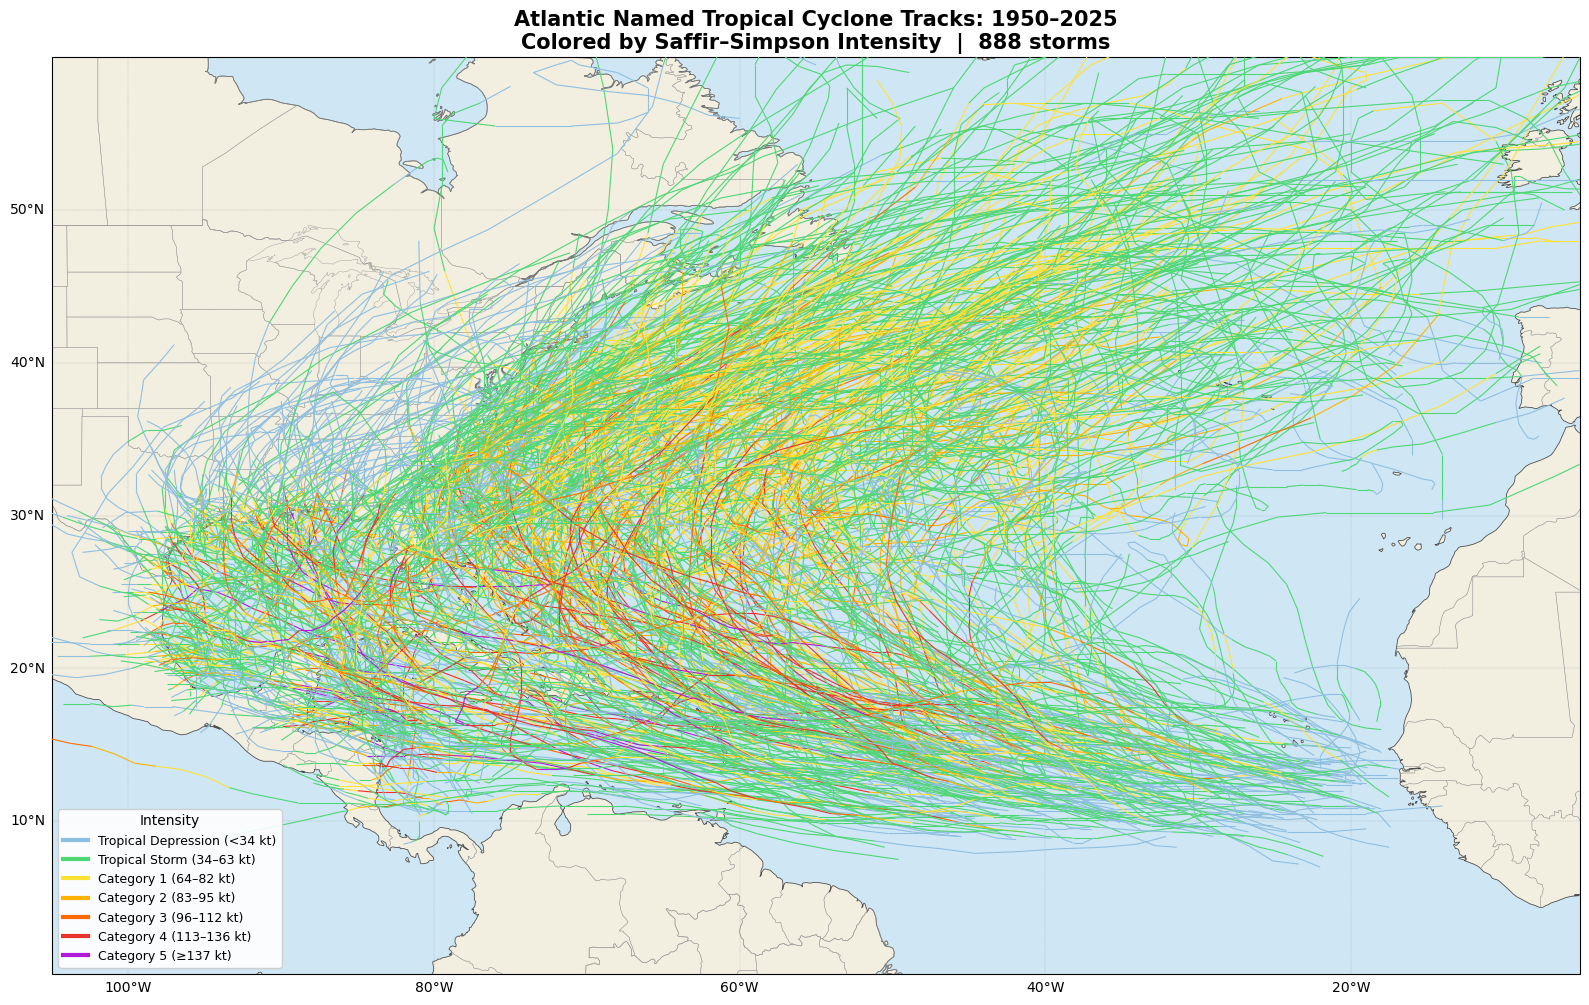

In [8]:
yearStart = named_storms_df['year'].min()
yearEnd   = named_storms_df['year'].max()

minlon, maxlon = -105., -5.
minlat, maxlat =    0., 60.

def build_segments_colors(tracks, storm_ids):
    segments, colors = [], []
    for sid in storm_ids:
        sub = tracks[tracks['storm_id'] == sid].sort_values('datetime')
        lon = sub['lon'].values
        lat = sub['lat'].values
        wind = sub['wind'].values
        for k in range(len(lon) - 1):
            segments.append([(lon[k], lat[k]), (lon[k + 1], lat[k + 1])])
            w = np.nanmax([wind[k], wind[k + 1]])
            colors.append(cat_colors[wind_to_category(w)])
    return segments, colors

fig, ax = make_basemap([minlon, maxlon, minlat, maxlat])

segments, colors = build_segments_colors(named_tracks_df, named_storms_df['storm_id'])
lc = LineCollection(segments, colors=colors, linewidths=0.8, transform=ccrs.PlateCarree(), zorder=3)
ax.add_collection(lc)

intensity_legend(ax)

ax.set_title(
    f"Atlantic Named Tropical Cyclone Tracks: {yearStart}\u2013{yearEnd}\n"
    f"Colored by Saffir\u2013Simpson Intensity  |  {len(named_storms_df)} storms",
    fontsize=15, fontweight='bold'
)

plt.tight_layout()
plt.show()


## 8. Plot 2: Look up a single storm's track by name and year

Storm names repeat across years (e.g. there have been several storms named "Alberto"), so both
**name** and **year** are needed to uniquely identify a storm.


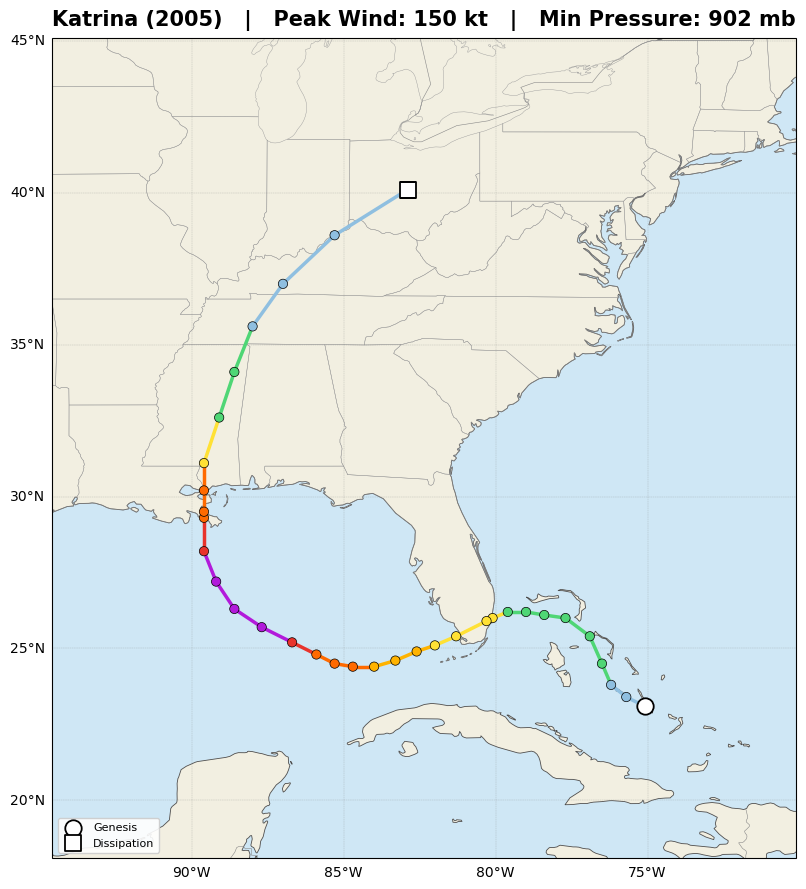

In [9]:
def get_storm(name, year):
    name_u = str(name).strip().upper()
    match = named_storms_df[
        (named_storms_df['name'].str.upper() == name_u) & (named_storms_df['year'] == int(year))
    ]
    if match.empty:
        raise ValueError(f"No named storm found matching '{name}' in {year}.")
    return match.iloc[0]


def plot_storm_track(name, year, pad=5.0):
    storm = get_storm(name, year)
    sid = storm['storm_id']
    sub = named_tracks_df[named_tracks_df['storm_id'] == sid].sort_values('datetime')

    lon = sub['lon'].values
    lat = sub['lat'].values
    wind = sub['wind'].values

    extent = [lon.min() - pad, lon.max() + pad,
              max(lat.min() - pad, -10.), lat.max() + pad]

    fig, ax = make_basemap(extent, figsize=(11, 9))

    # colored track line
    segs = [[(lon[k], lat[k]), (lon[k + 1], lat[k + 1])] for k in range(len(lon) - 1)]
    seg_colors = [cat_colors[wind_to_category(np.nanmax([wind[k], wind[k + 1]]))]
                  for k in range(len(lon) - 1)]
    lc = LineCollection(segs, colors=seg_colors, linewidths=2.5, transform=ccrs.PlateCarree(), zorder=3)
    ax.add_collection(lc)

    # category-colored dot at each observation, like NHC storm symbols
    dot_colors = [cat_colors[wind_to_category(w)] for w in wind]
    ax.scatter(lon, lat, c=dot_colors, s=45, edgecolor='black', linewidth=0.5,
               transform=ccrs.PlateCarree(), zorder=4)

    # genesis / dissipation markers
    ax.scatter(lon[0], lat[0], marker='o', s=140, facecolor='white', edgecolor='black',
               linewidth=1.3, transform=ccrs.PlateCarree(), zorder=5, label='Genesis')
    ax.scatter(lon[-1], lat[-1], marker='s', s=140, facecolor='white', edgecolor='black',
               linewidth=1.3, transform=ccrs.PlateCarree(), zorder=5, label='Dissipation')

    max_wind = np.nanmax(wind)
    min_pres = sub['pressure'].min()

    title = f"{storm['name'].title()} ({storm['year']})   |   Peak Wind: {int(max_wind)} kt"
    if not np.isnan(min_pres):
        title += f"   |   Min Pressure: {int(min_pres)} mb"
    ax.set_title(title, fontsize=15, fontweight='bold')

    intensity_legend(ax, loc='lower left', fontsize=8)
    ax.legend(*ax.get_legend_handles_labels(), loc='lower left', fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.show()


# Example: call this directly with any named storm + year
plot_storm_track("Katrina", 2005)


## 9. Interactive storm picker
Pick a year, then a storm name from that year, and click **Plot Track**.
(Requires `ipywidgets`)

In [10]:
import ipywidgets as widgets
from IPython.display import display

years_sorted = sorted(named_storms_df['year'].unique(), reverse=True)

def get_names_for_year(year):
    return sorted(named_storms_df.loc[named_storms_df['year'] == year, 'name'].unique())

year_dropdown = widgets.Dropdown(options=years_sorted, description='Year:')
name_dropdown = widgets.Dropdown(options=get_names_for_year(years_sorted[0]), description='Storm:')
plot_button = widgets.Button(description='Plot Track', button_style='primary')
output = widgets.Output()

def on_year_change(change):
    name_dropdown.options = get_names_for_year(change['new'])

def on_button_click(b):
    with output:
        output.clear_output(wait=True)
        plot_storm_track(name_dropdown.value, year_dropdown.value)

year_dropdown.observe(on_year_change, names='value')
plot_button.on_click(on_button_click)

display(widgets.HBox([year_dropdown, name_dropdown, plot_button]), output)


Output()